In [175]:
!which python
%load_ext autoreload
%autoreload 2
!pip install --upgrade earthengine-api

/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/bin/python
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [164]:
#If there are issues with importing modules. This is for reloading a module
import importlib
import computations_funcs
import plot_funcs
import data_collection
module=data_collection
importlib.reload(module)

<module 'data_collection' from '/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/data_collection.py'>

In [252]:
import ee
from dotenv import load_dotenv
import os
from data_collection import get_state_districs,get_region_for_districts,generate_mask_for_region,get_data_for_districts
import numpy as np
import matplotlib.pyplot as plt
from computations_funcs import smooth_stack_from_array_dict , resize_img ,generate_probability_mask,convert_smooth_data_to_bins,create_balanced_csv
from data_initialization import categorical_labels,band_cmaps,mcdm_weights
from plot_funcs import plot_bands_one_by_one
import matplotlib.colors as mcolors



load_dotenv()

PROJECT_NAME = os.getenv("PROJECT_NAME")
if PROJECT_NAME is None:
    raise Exception("Please set the PROJECT_NAME environment variable")

In [253]:
print('Initializing Earth Engine')
try:
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')
except Exception as e:
    print('Initializing Earth Engine for the first time')
    ee.Authenticate()
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')
# NOTE: This is a test to check if ee is initialized
# image = ee.Image('USGS/SRTMGL1_003')
# print(image.getInfo())

Initializing Earth Engine
Successfully initialized Earth Engine Project be-project-aaronfurtado2003


In [254]:
state=''
while(state==''):
    state=input("Please Enter a state name:")

state_source,districts=get_state_districs(state)
print(f'List of Districts in {state} are:\n{districts}')
print('\n')
selected_districts_unfiltered=input("Please Enter the name of the Districts separated by comma:\n")
selected_districts=selected_districts_unfiltered.split(',')
selected_districts=[district.strip() for district in selected_districts]

print(f'Selected Districts are:\n{selected_districts}')

List of Districts in Maharashtra are:
['Nandurbar', 'Akola', 'Amravati', 'Bhandara', 'Buldana', 'Chandrapur', 'Dhule', 'Garhchiroli', 'Jalgaon', 'Kolhapur', 'Latur', 'Nagpur', 'Nanded', 'Nashik', 'Osmanabad', 'Pune', 'Raigarh', 'Ratnagiri', 'Sindhudurg', 'Sangli', 'Satara', 'Solapur', 'Thane', 'Wardha', 'Yavatmal', 'Aurangabad', 'Ahmednagar', 'Bid', 'Gondiya', 'Hingoli', 'Jalna', 'Mumbai Suburban', 'Mumbai city', 'Parbhani', 'Washim']


Selected Districts are:
['Aurangabad', 'Bid', 'Jalna', 'Latur', 'Nanded', 'Osmanabad', 'Parbhani', 'Hingoli']


In [256]:
print(f'Collecting data for {selected_districts}')
print(f'Getting region scale and boundary for districts')
region,scale,region_self_mask=get_region_for_districts(state_source,selected_districts)

print(f'Generating masks for selected region')
mask_projection,region_mask=generate_mask_for_region(region,scale)

print(f'Collecting data for {selected_districts}')
array_dict=get_data_for_districts(region,scale,mask_projection,region_self_mask)

Getting region scale and boundary for districts
Generating masks for selected region
--- Bands in final "stack" object: ['dem', 'slope', 'lulc', 'soilTx', 'geom', 'rain', 'ndwi', 'soil_moisture', 'runoff_coeff', 'dist_to_water', 'stream_order', 'flow_acc']
--- Bands in "masked_stack" object: ['dem', 'slope', 'lulc', 'soilTx', 'geom', 'rain', 'ndwi', 'soil_moisture', 'runoff_coeff', 'dist_to_water', 'stream_order', 'flow_acc']
date_range
Band not found: date_range
dem
Band found: dem
Appended band: dem
description
Band not found: description
dist_to_water
Band found: dist_to_water
Appended band: dist_to_water
flow_acc
Band found: flow_acc
Appended band: flow_acc
geom
Band found: geom
Appended band: geom
keywords
Band not found: keywords
lulc
Band found: lulc
Appended band: lulc
ndwi
Band found: ndwi
Appended band: ndwi
period
Band not found: period
product_tags
Band not found: product_tags
provider
Band not found: provider
provider_url
Band not found: provider_url
rain
Band found: rain


In [257]:
array_dict['properties'].keys()

dict_keys(['dem', 'dist_to_water', 'flow_acc', 'geom', 'lulc', 'ndwi', 'rain', 'runoff_coeff', 'slope', 'soilTx', 'soil_moisture', 'stream_order'])

In [258]:
print(f'Resizing and smoothing collected data')
smoothed_stack,band_names=smooth_stack_from_array_dict(array_dict,categorical_bands=categorical_labels.keys())
print(f'Stack shape: {smoothed_stack.shape}')
print(f'Band names: {band_names}')

Resizing and smoothing collected data
Stack shape: (512, 605, 12)
Band names: ['dem', 'dist_to_water', 'flow_acc', 'geom', 'lulc', 'ndwi', 'rain', 'runoff_coeff', 'slope', 'soilTx', 'soil_moisture', 'stream_order']


In [259]:
print(f'Converting continous data into bins using kmeans')
tiers,breaks=convert_smooth_data_to_bins(smoothed_stack,band_names,n_classes=5)


Converting continous data into bins using kmeans


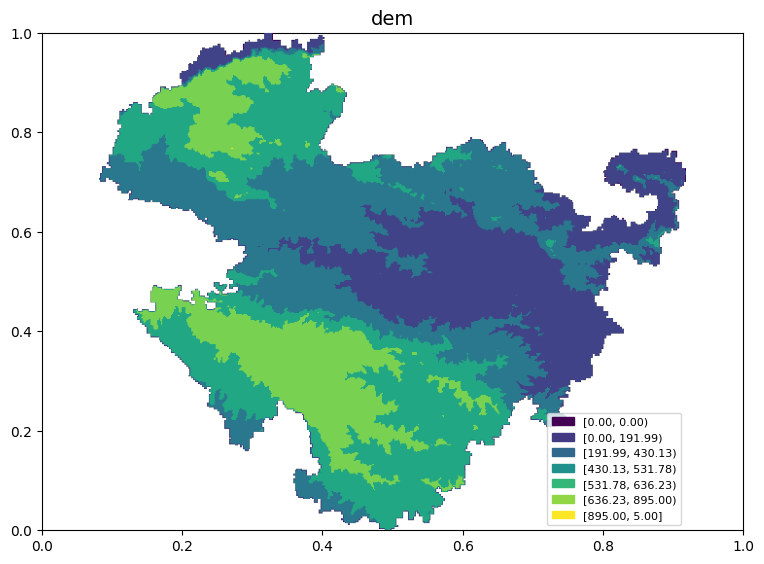

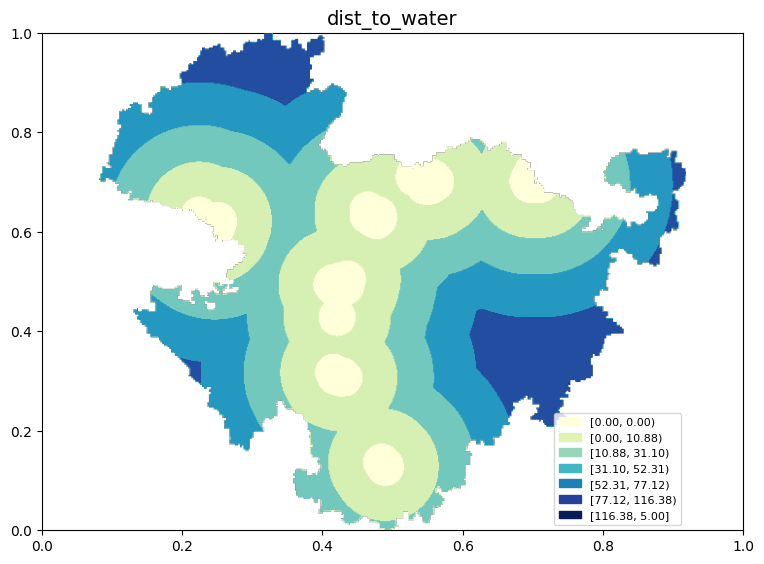

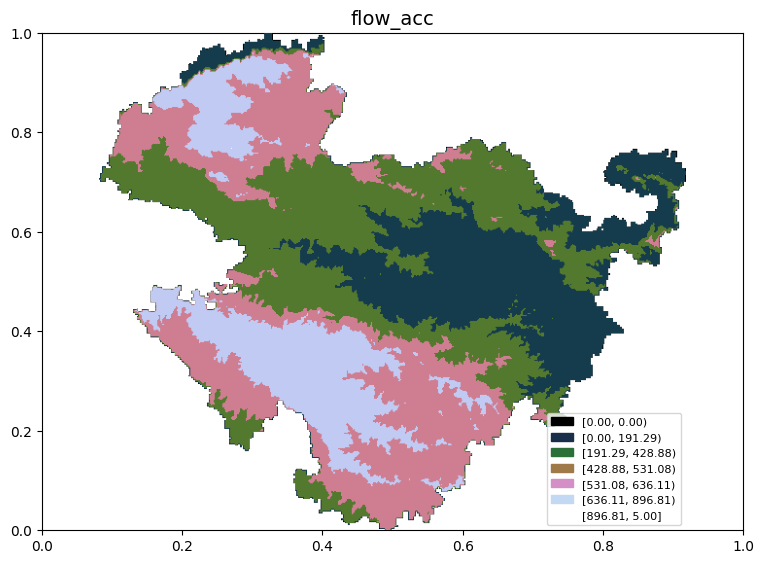

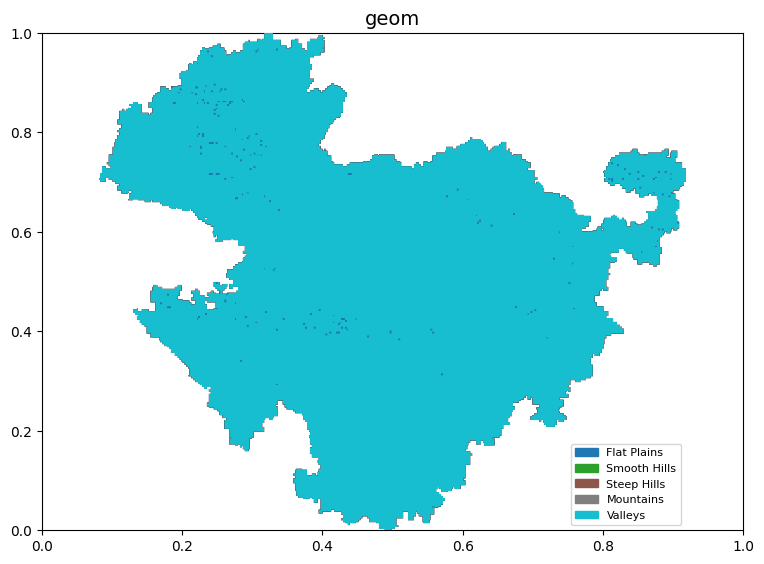

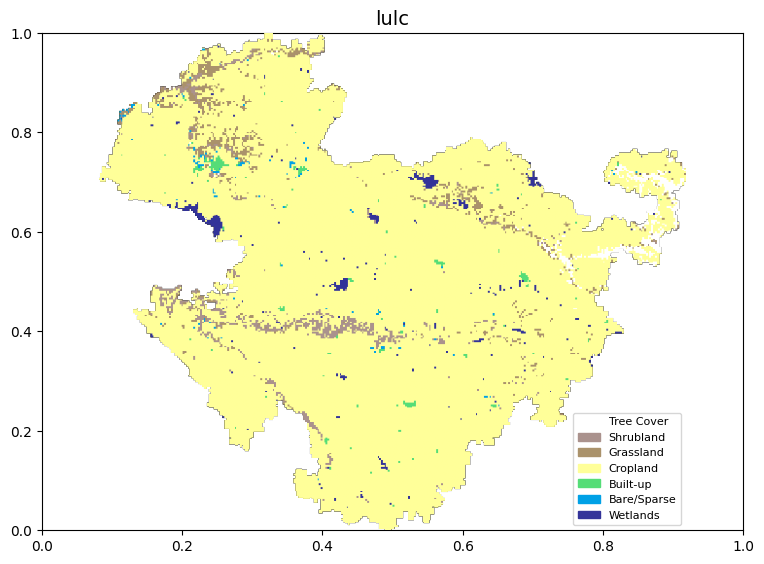

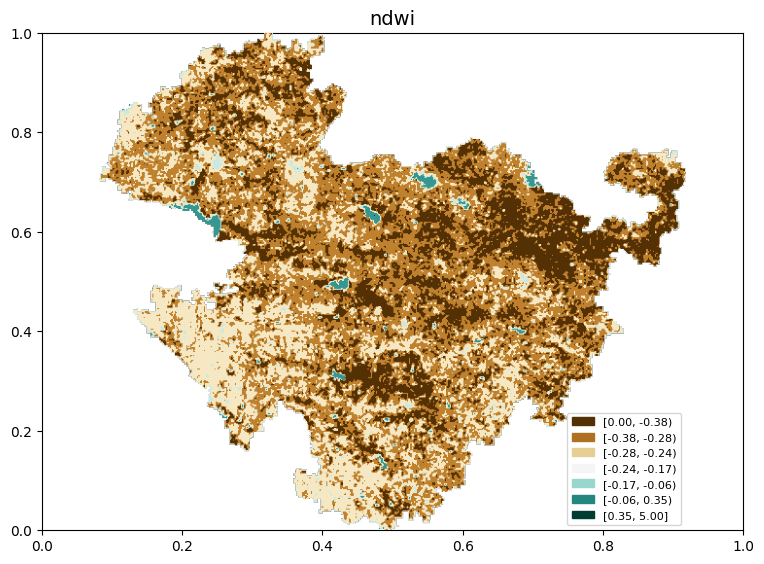

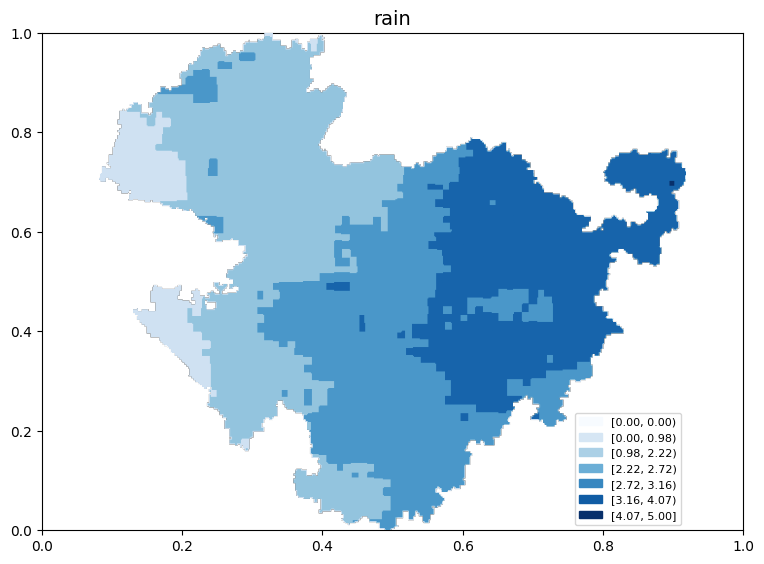

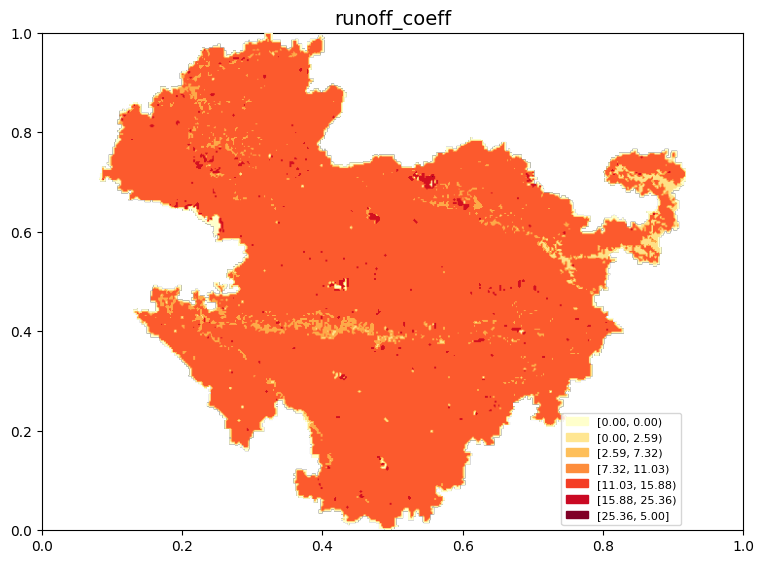

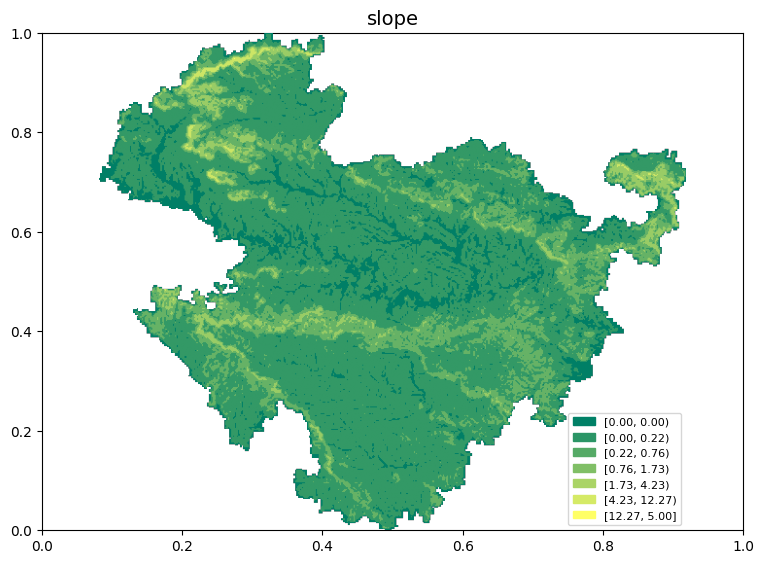

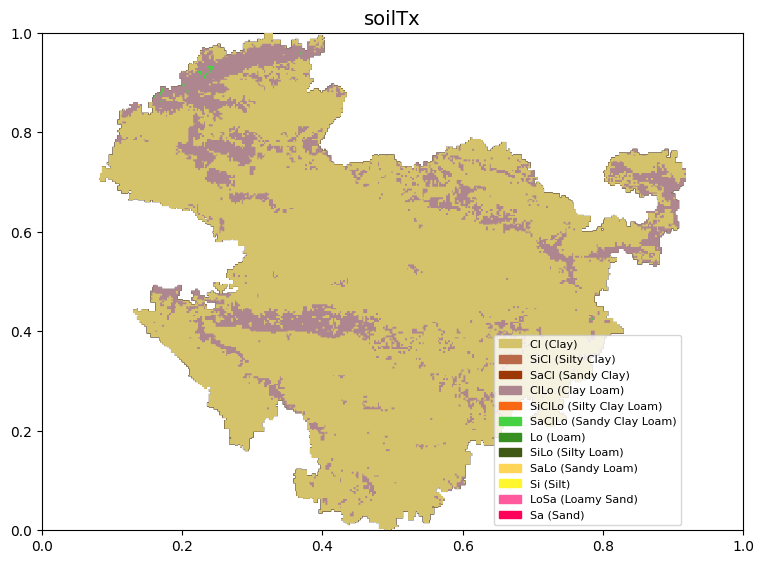

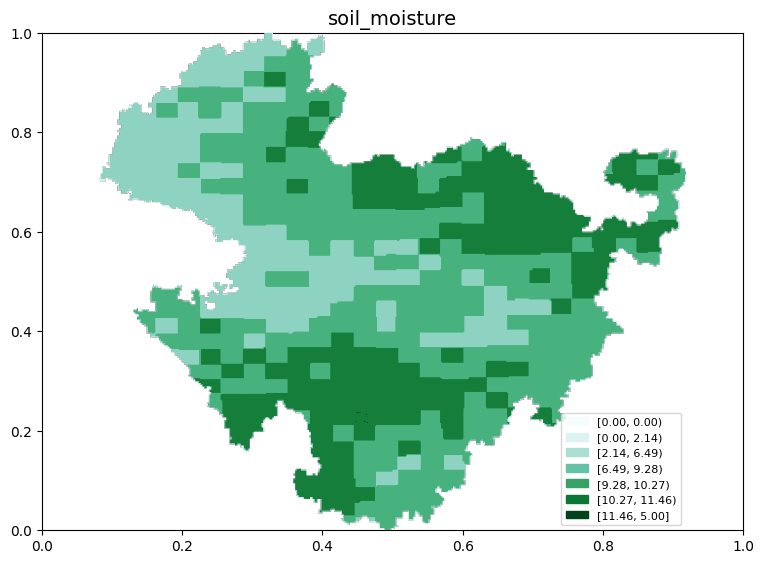

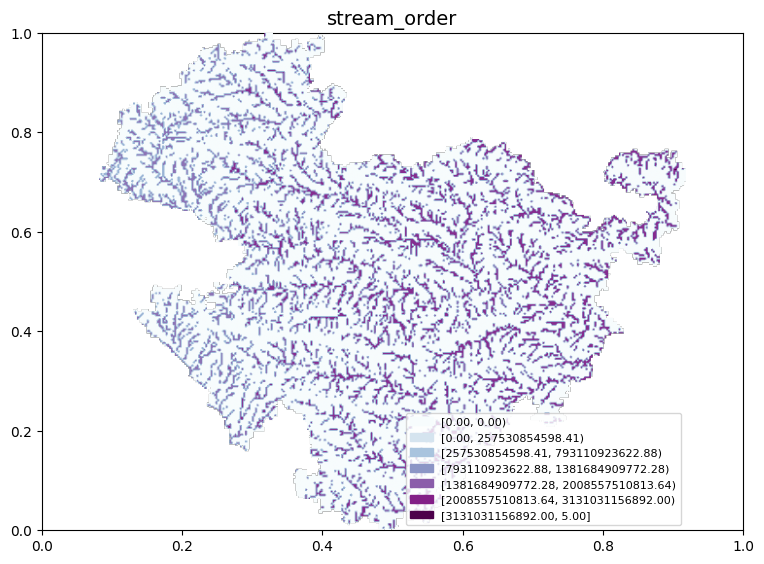

In [261]:
plot_choice=''
while(plot_choice.lower() not in ['y','n']):
    plot_choice=input("Do you want to plot the data? (y/n):")
    if plot_choice.lower()=='y':
        plot_bands_one_by_one(
            smoothed_stack=tiers,
            band_names=band_names,
            region_mask=resize_img(region_mask)
            ,band_cmaps=band_cmaps,
            categorical_labels=categorical_labels,
            breaks=breaks
            )
    else:
        print('No problem!')

stacked shape: (512, 605, 12)
wts shape: (12,)


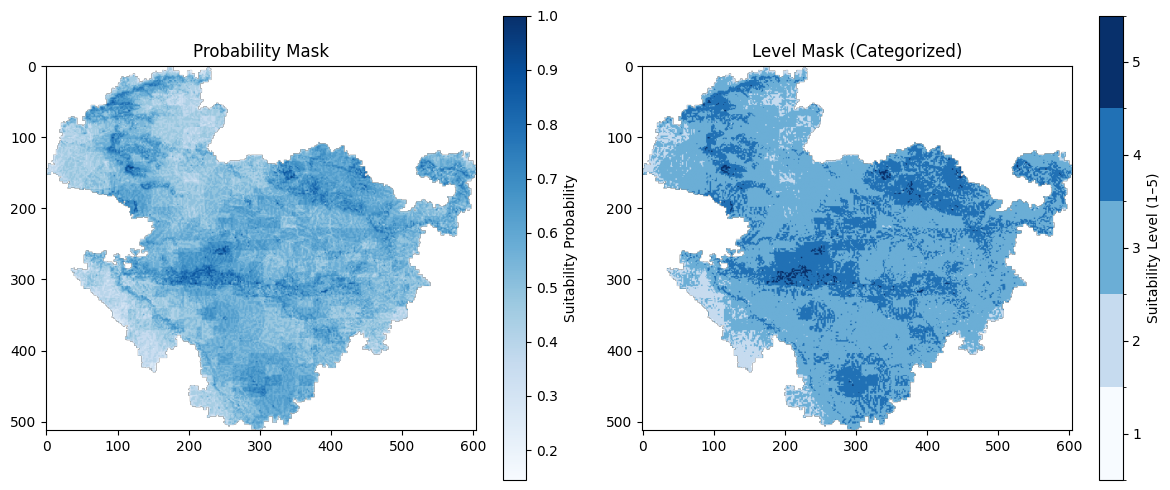

In [262]:
prob_mask, level_mask, weighted_sum  = generate_probability_mask(data=[x for x in tiers.values()],band_names=band_names,weights=mcdm_weights)
masked_prob = (np.where(resize_img(region_mask) == 1, prob_mask, np.nan))
masked_level =( np.where(resize_img(region_mask) == 1, level_mask, np.nan))
plt.figure(figsize=(12, 5))

# Plot probability mask
plt.subplot(1, 2, 1)
plt.imshow(masked_prob, cmap='Blues')
plt.colorbar(label='Suitability Probability')
plt.title('Probability Mask')

# Plot level mask
plt.subplot(1, 2, 2)
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], ncolors=5)
im = plt.imshow(masked_level, plt.get_cmap('Blues', 5), norm=norm)
cbar = plt.colorbar(im, ticks=[1, 2, 3, 4, 5])
cbar.set_label('Suitability Level (1–5)')
plt.title('Level Mask (Categorized)')
plt.tight_layout()
plt.show()

In [263]:
name=input('Enter a file name:\n')
transposed_tiers=np.transpose(np.array([np.array(x) for x in tiers.values()]),(1,2,0))
dataset=create_balanced_csv(smoothed_stack,resize_img(level_mask),resize_img(prob_mask),band_names,resize_img(region_mask),3000,23,name=f'continous_{name}_dataset')
dataset2=create_balanced_csv(transposed_tiers,resize_img(level_mask),resize_img(prob_mask),band_names,resize_img(region_mask),3000,23,name=f'transposed_{name}_dataset')

Valid flat_level:[1 2 3 4 5 6]
(156765, 12)
⚠️ Not enough samples for level 1. Found: 19
✅ Saved to 'continous_marathwada_dataset.csv'
Valid flat_level:[1 2 3 4 5 6]
(156765, 12)
⚠️ Not enough samples for level 1. Found: 19
✅ Saved to 'transposed_marathwada_dataset.csv'


In [250]:
np.transpose(np.array([np.array(x) for x in tiers.values()]),(1,2,0)).shape

(516, 512, 12)

In [249]:
smoothed_stack.shape

(516, 512, 12)